In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, classification_report

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [53]:
# =========================
# CONFIG
# =========================
CSV_PATH     = r"abm_tipping_summary_50000.csv"
PARAMS       = ["n", "m", "P_0", "c", "d", "k", "R", "z"]
TEST_SIZE    = 0.25
RANDOM_STATE = 42
N_ESTIMATORS = 300
N_REPEATS    = 20

plt.rcParams["font.family"] = "Times New Roman"
TITLE_FS = 18
LABEL_FS = 16
TICK_FS  = 12
BAR_COLOR = "lightsteelblue"
ERR_COLOR = "navy"


In [54]:
# =========================
# CONFIG
# =========================
CSV_PATH     = r"abm_tipping_summary_50000.csv"
PARAMS       = ["n", "m", "P_0", "c", "d", "k", "R", "z"]
TEST_SIZE    = 0.25
RANDOM_STATE = 42
N_ESTIMATORS = 300
N_REPEATS    = 20

plt.rcParams["font.family"] = "Times New Roman"
TITLE_FS = 18
LABEL_FS = 16
TICK_FS  = 12
BAR_COLOR = "lightsteelblue"
ERR_COLOR = "navy"

# =========================
# LOAD
# =========================
df = pd.read_csv(r"D:\WOA_Exploration\doc\abm_tipping_summary_50000.csv")
X  = df[PARAMS].copy()
y  = df["full_collapse"].astype(int)

print(f"Classe 0 (non-collapsed): {(y == 0).sum()}")
print(f"Classe 1 (collapsed):     {(y == 1).sum()}")

# =========================
# TRAIN
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train, y_train)

auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print(f"\nAUC-ROC = {auc:.3f}")
print(classification_report(y_test, rf.predict(X_test),
                             target_names=["non-collapsed", "collapsed"]))

# =========================
# PERMUTATION IMPORTANCE
# =========================
perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    n_jobs=-1
)

imp = pd.DataFrame({
    "parameter":       PARAMS,
    "importance_mean": perm.importances_mean,
    "importance_std":  perm.importances_std
}).sort_values("importance_mean", ascending=True)

print("\n", imp.to_string(index=False))


Classe 0 (non-collapsed): 22833
Classe 1 (collapsed):     27167

AUC-ROC = 0.983
               precision    recall  f1-score   support

non-collapsed       0.94      0.91      0.93      5708
    collapsed       0.93      0.95      0.94      6792

     accuracy                           0.93     12500
    macro avg       0.93      0.93      0.93     12500
 weighted avg       0.93      0.93      0.93     12500


 parameter  importance_mean  importance_std
        d         0.000000        0.000000
        z         0.001195        0.000221
      P_0         0.001346        0.000215
        k         0.006374        0.000339
        R         0.012729        0.000349
        c         0.012765        0.000542
        n         0.062405        0.001041
        m         0.415955        0.004732


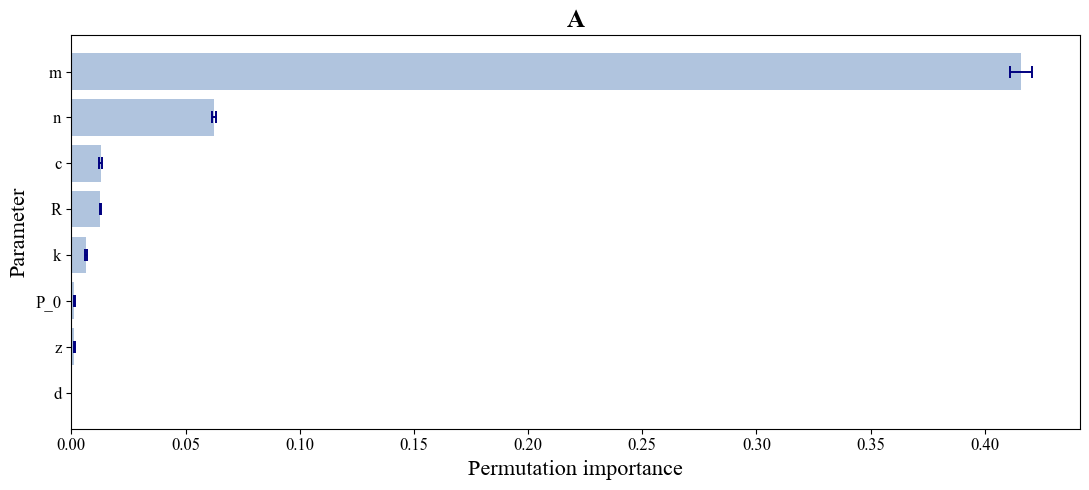

In [55]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.barh(
    imp["parameter"],
    imp["importance_mean"],
    xerr=imp["importance_std"],
    color=BAR_COLOR,
    error_kw=dict(ecolor=ERR_COLOR, lw=1.4, capsize=4, capthick=1.4)
)

ax.set_xlabel("Permutation importance", fontsize=LABEL_FS)
ax.set_ylabel("Parameter", fontsize=LABEL_FS)
ax.set_title("A", fontsize=TITLE_FS, fontweight="bold")
ax.tick_params(axis="both", labelsize=TICK_FS)

plt.tight_layout()
plt.savefig("parameter_importance_collapse.png", dpi=200, bbox_inches="tight")
plt.show()

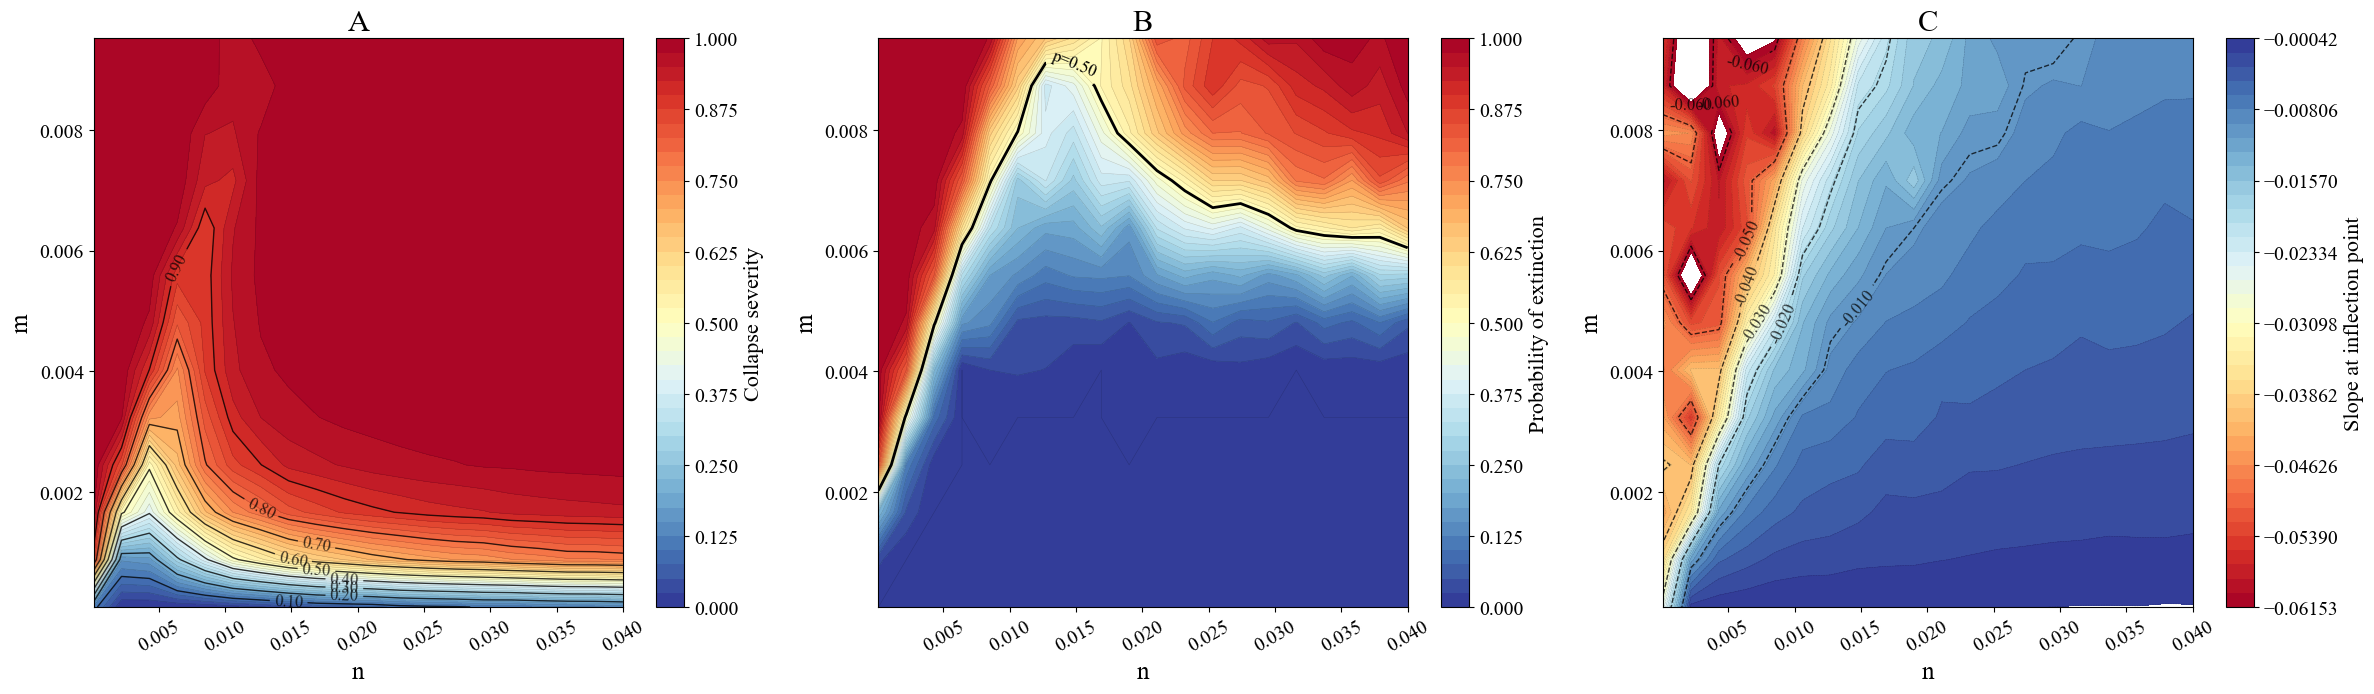

In [68]:
# =========================
# CONFIG
# =========================
CSV_PATH = r"D:\WOA_Exploration\doc\abm_tipping_summary_50000.csv"

plt.rcParams["font.family"] = "Times New Roman"

TITLE_FS   = 22
LABEL_FS   = 18
TICK_FS    = 14
CBAR_FS    = 16
CLABEL_FS  = 12

FIGSIZE = (24, 7)
BG_COLOR = "white"

CMAP_A = "RdYlBu_r"
CMAP_B = "RdYlBu_r"
CMAP_C = "RdYlBu"

# =========================
# LOAD
# =========================
df = pd.read_csv(CSV_PATH)
df = df[df["m"] <= 0.010]
df["collapse_severity"] = 1 - df["collapse_metric"]

# =========================
# PIVOT TABLES
# =========================
heat1 = df.pivot_table(index="m", columns="n", values="collapse_severity",  aggfunc="mean").sort_index().sort_index(axis=1)
heat2 = df.pivot_table(index="m", columns="n", values="full_collapse",       aggfunc="mean").sort_index().sort_index(axis=1)
heat3 = df.pivot_table(index="m", columns="n", values="slope_inflection",    aggfunc="mean").sort_index().sort_index(axis=1)

def make_mesh(heat):
    x = heat.columns.to_numpy(dtype=float)
    y = heat.index.to_numpy(dtype=float)
    X, Y = np.meshgrid(x, y)
    Z = heat.to_numpy(dtype=float)
    return X, Y, Z

X1, Y1, Z1 = make_mesh(heat1)
X2, Y2, Z2 = make_mesh(heat2)
X3, Y3, Z3 = make_mesh(heat3)

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, facecolor=BG_COLOR)

for ax in axes:
    ax.set_facecolor(BG_COLOR)

# ── PANEL A ──────────────────────────────────────────────────────────────────
cf1 = axes[0].contourf(X1, Y1, Z1, levels=np.linspace(0, 1, 41), cmap=CMAP_A)
axes[0].contour(X1, Y1, Z1, levels=np.linspace(0, 1, 41), colors="k", linewidths=0.35, alpha=0.25)
cs1 = axes[0].contour(X1, Y1, Z1, levels=np.arange(0.1, 1.0, 0.1), colors="k", linewidths=1.0, alpha=0.75)
axes[0].clabel(cs1, inline=True, fontsize=CLABEL_FS, fmt="%.2f")

cbar1 = fig.colorbar(cf1, ax=axes[0])
cbar1.set_label("Collapse severity", fontsize=CBAR_FS)
cbar1.ax.tick_params(labelsize=TICK_FS)

axes[0].set_xlabel("n", fontsize=LABEL_FS)
axes[0].set_ylabel("m", fontsize=LABEL_FS)
axes[0].set_title("A", fontsize=TITLE_FS)
axes[0].tick_params(axis="x", labelrotation=30, labelsize=TICK_FS)
axes[0].tick_params(axis="y", labelsize=TICK_FS)

# ── PANEL B ──────────────────────────────────────────────────────────────────
cf2 = axes[1].contourf(X2, Y2, Z2, levels=np.linspace(0, 1, 41), cmap=CMAP_B)
axes[1].contour(X2, Y2, Z2, levels=np.linspace(0, 1, 41), colors="k", linewidths=0.35, alpha=0.20)
cs2 = axes[1].contour(X2, Y2, Z2, levels=[0.5], colors="k", linewidths=2.0)
axes[1].clabel(cs2, inline=True, fontsize=CLABEL_FS, fmt={0.5: "p=0.50"})

cbar2 = fig.colorbar(cf2, ax=axes[1])
cbar2.set_label("Probability of extinction", fontsize=CBAR_FS)
cbar2.ax.tick_params(labelsize=TICK_FS)

axes[1].set_xlabel("n", fontsize=LABEL_FS)
axes[1].set_ylabel("m", fontsize=LABEL_FS)
axes[1].set_title("B", fontsize=TITLE_FS)
axes[1].tick_params(axis="x", labelrotation=30, labelsize=TICK_FS)
axes[1].tick_params(axis="y", labelsize=TICK_FS)

# ── PANEL C ──────────────────────────────────────────────────────────────────
vmin3 = np.nanpercentile(Z3, 2)
vmax3 = np.nanpercentile(Z3, 98)
levels3 = np.linspace(vmin3, vmax3, 41)

cf3 = axes[2].contourf(X3, Y3, Z3, levels=levels3, cmap=CMAP_C)
axes[2].contour(X3, Y3, Z3, levels=levels3, colors="k", linewidths=0.35, alpha=0.25)
cs3 = axes[2].contour(X3, Y3, Z3, levels=6, colors="k", linewidths=1.0, alpha=0.75)
axes[2].clabel(cs3, inline=True, fontsize=CLABEL_FS, fmt="%.3f")

cbar3 = fig.colorbar(cf3, ax=axes[2])
cbar3.set_label("Slope at inflection point", fontsize=CBAR_FS)
cbar3.ax.tick_params(labelsize=TICK_FS)

axes[2].set_xlabel("n", fontsize=LABEL_FS)
axes[2].set_ylabel("m", fontsize=LABEL_FS)
axes[2].set_title("C", fontsize=TITLE_FS)
axes[2].tick_params(axis="x", labelrotation=30, labelsize=TICK_FS)
axes[2].tick_params(axis="y", labelsize=TICK_FS)

plt.tight_layout()
plt.savefig("heatmaps_ABC.png", dpi=200, bbox_inches="tight")
plt.show()

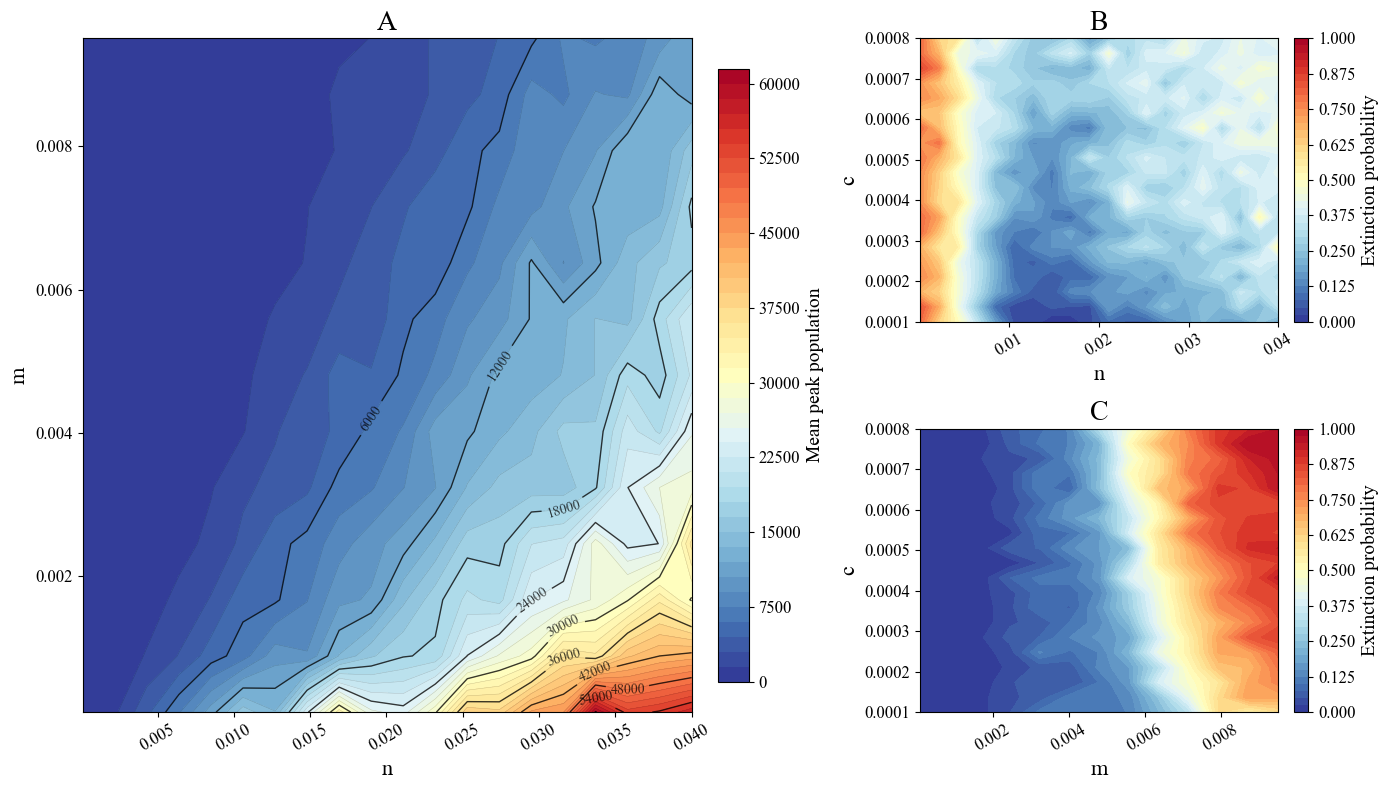

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# =========================
# CONFIG
# =========================
CSV_PATH = "doc/abm_tipping_summary_50000.csv"

plt.rcParams["font.family"] = "Times New Roman"

TITLE_FS   = 20
LABEL_FS   = 16
TICK_FS    = 12
CBAR_FS    = 14
CLABEL_FS  = 10

FIGSIZE  = (14, 8)
BG_COLOR = "white"

CMAP_A = "RdYlBu_r"
CMAP_B = "RdYlBu_r"

# =========================
# LOAD
# =========================
df = pd.read_csv(CSV_PATH)
df = df[df["m"] <= 0.010]

def make_heat(df, row, col, value):
    heat = df.pivot_table(
        index=row,
        columns=col,
        values=value,
        aggfunc="mean"
    ).sort_index().sort_index(axis=1)

    x = heat.columns.to_numpy(dtype=float)
    y = heat.index.to_numpy(dtype=float)
    X, Y = np.meshgrid(x, y)
    Z = heat.to_numpy(dtype=float)
    return X, Y, Z

# A = P_peak su (m, n)
X1, Y1, Z1 = make_heat(df, "m", "n", "P_peak")

# B, C = extinction probability con c
X2, Y2, Z2 = make_heat(df, "c", "n", "full_collapse")
X3, Y3, Z3 = make_heat(df, "c", "m", "full_collapse")

# =========================
# LAYOUT
# =========================
fig = plt.figure(figsize=FIGSIZE, facecolor=BG_COLOR)
gs = GridSpec(2, 2, width_ratios=[1.7, 1], height_ratios=[1, 1], figure=fig)

ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(BG_COLOR)

# =========================
# A: P_peak su (n, m)
# =========================
cf1 = ax1.contourf(X1, Y1, Z1, levels=40, cmap=CMAP_A)
ax1.contour(X1, Y1, Z1, levels=40, colors="k", linewidths=0.35, alpha=0.20)
cs1 = ax1.contour(X1, Y1, Z1, levels=10, colors="k", linewidths=1.0, alpha=0.75)
ax1.clabel(cs1, inline=True, fontsize=CLABEL_FS, fmt="%.0f")

cbar1 = fig.colorbar(cf1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label("Mean peak population", fontsize=CBAR_FS)
cbar1.ax.tick_params(labelsize=TICK_FS)

ax1.set_title("A", fontsize=TITLE_FS)
ax1.set_xlabel("n", fontsize=LABEL_FS)
ax1.set_ylabel("m", fontsize=LABEL_FS)
ax1.tick_params(axis="x", labelrotation=30, labelsize=TICK_FS)
ax1.tick_params(axis="y", labelsize=TICK_FS)

# =========================
# B: extinction probability su (c, n)
# =========================
cf2 = ax2.contourf(X2, Y2, Z2, levels=np.linspace(0, 1, 41), cmap=CMAP_B)

cbar2 = fig.colorbar(cf2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label("Extinction probability", fontsize=CBAR_FS)
cbar2.ax.tick_params(labelsize=TICK_FS)

ax2.set_title("B", fontsize=TITLE_FS)
ax2.set_xlabel("n", fontsize=LABEL_FS)
ax2.set_ylabel("c", fontsize=LABEL_FS)
ax2.tick_params(axis="x", labelrotation=30, labelsize=TICK_FS)
ax2.tick_params(axis="y", labelsize=TICK_FS)

# =========================
# C: extinction probability su (c, m)
# =========================
cf3 = ax3.contourf(X3, Y3, Z3, levels=np.linspace(0, 1, 41), cmap=CMAP_B)

cbar3 = fig.colorbar(cf3, ax=ax3, fraction=0.046, pad=0.04)
cbar3.set_label("Extinction probability", fontsize=CBAR_FS)
cbar3.ax.tick_params(labelsize=TICK_FS)

ax3.set_title("C", fontsize=TITLE_FS)
ax3.set_xlabel("m", fontsize=LABEL_FS)
ax3.set_ylabel("c", fontsize=LABEL_FS)
ax3.tick_params(axis="x", labelrotation=30, labelsize=TICK_FS)
ax3.tick_params(axis="y", labelsize=TICK_FS)

plt.tight_layout()
plt.savefig("heatmaps_c.png", dpi=200, bbox_inches="tight")
plt.show()

In [81]:
# =========================
# CONFIG
# =========================
OUTPUT_PATH = r"D:\WOA_Exploration\doc\abm_tipping_timeseries_50000.csv"

T          = 2500
N_SIMS     = 500
S_0        = 0.0

# parametri fissi per le 3 configurazioni
FIXED_M    = 0.004
TARGET_NS  = [0.001, 0.006, 0.015]

# parametri liberi: range dal CSV originale
C_RANGE  = (0.0001, 0.0008)
D_RANGE  = (1e-8,   6e-8)
K_RANGE  = (10,     60)
R_RANGE  = (1000,   8000)
Z_RANGE  = (2,      30)
P0_RANGE = (5,      200)

# =========================
# RUN
# =========================
records = []

for target_n in TARGET_NS:
    print(f"\n--- n={target_n}, m={FIXED_M} ---")

    for sim_idx in range(N_SIMS):
        # campiono i parametri liberi uniformemente
        c   = np.random.uniform(*C_RANGE)
        d   = np.random.uniform(*D_RANGE)
        k   = np.random.uniform(*K_RANGE)
        R   = np.random.uniform(*R_RANGE)
        z   = int(np.random.randint(Z_RANGE[0], Z_RANGE[1] + 1))
        P_0 = int(np.random.randint(P0_RANGE[0], P0_RANGE[1] + 1))

        model = IndividualModel(
            T=T, c=c, m=FIXED_M, n=target_n,
            d=d, k=k, R=R, P_0=P_0, s_0=S_0, z=z
        )
        model.setup()
        model.run()

        for t, P in enumerate(model.P_ts):
            records.append({
                "config":  f"n={target_n}",
                "sim_id":  sim_idx,
                "n":       target_n,
                "m":       FIXED_M,
                "t":       t,
                "P":       int(P)
            })

        if (sim_idx + 1) % 50 == 0:
            print(f"  {sim_idx + 1}/{N_SIMS} done")

# =========================
# SAVE
# =========================
df = pd.DataFrame(records)
df.to_csv(OUTPUT_PATH, index=False)
print(f"\nSalvato: {OUTPUT_PATH}")
print(f"Righe totali: {len(df)}")


--- n=0.001, m=0.004 ---
  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done
  500/500 done

--- n=0.006, m=0.004 ---
  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done
  500/500 done

--- n=0.015, m=0.004 ---
  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done
  500/500 done

Salvato: D:\WOA_Exploration\doc\abm_tipping_timeseries_50000.csv
Righe totali: 3751500


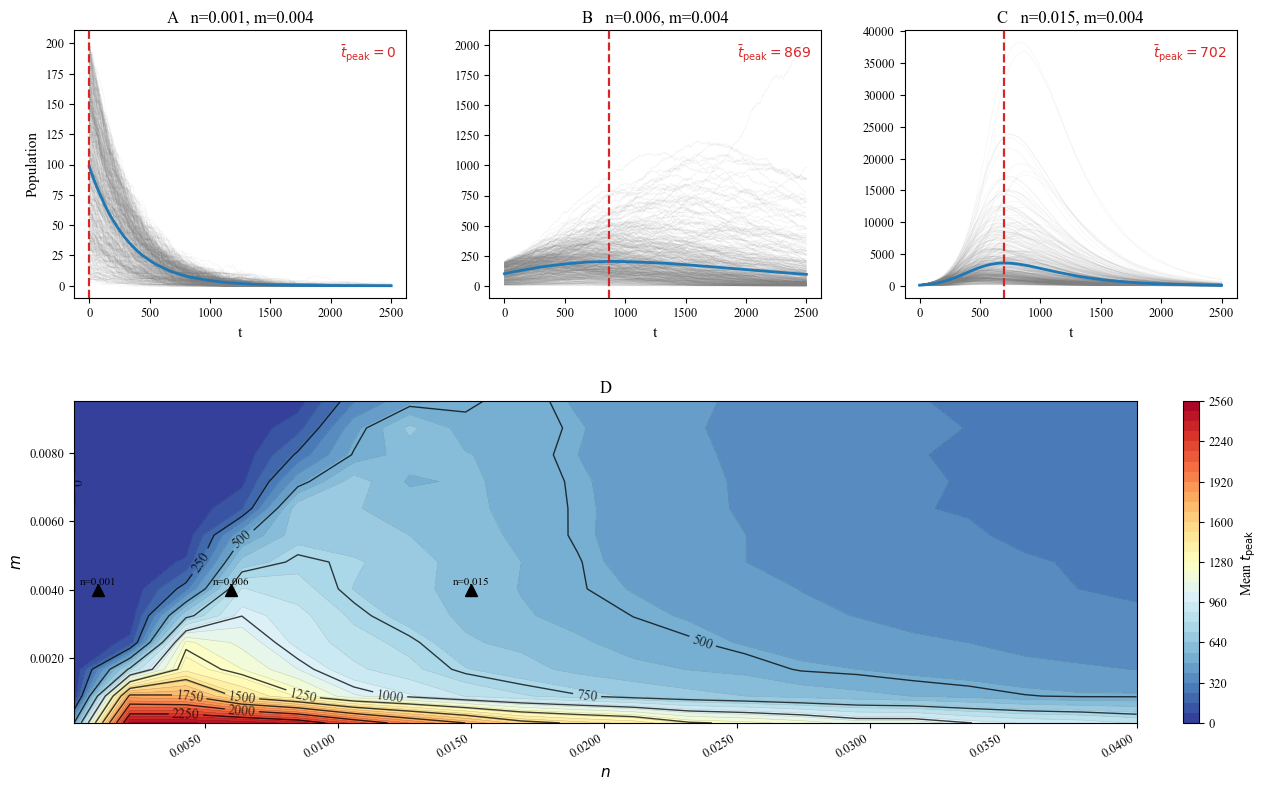

Salvato: D:\WOA_Exploration\doc\figure_trajectories_tpeak.png


In [82]:
# ── Config ────────────────────────────────────────────────────────────────────
TRAJ_PATH    = r"D:\WOA_Exploration\doc\abm_tipping_timeseries_50000.csv"
SUMMARY_PATH = r"D:\WOA_Exploration\doc\abm_tipping_summary_50000.csv"
OUTPUT_PATH  = r"D:\WOA_Exploration\doc\figure_trajectories_tpeak.png"

plt.rcParams["font.family"] = "Times New Roman"

TITLE_FS   = 12
LABEL_FS   = 11
TICK_FS    = 9
CBAR_FS    = 10
CLABEL_FS  = 10
FIGSIZE    = (15, 9)

LINE_COLOR  = "gray"
LINE_ALPHA  = 0.08
LINE_WIDTH  = 0.5
MEAN_COLOR  = "#1f77b4"
MEAN_LW     = 2.0
VLINE_COLOR = "#d62728"
VLINE_LW    = 1.6

TARGET_NS  = [0.001, 0.006, 0.015]
FIXED_M    = 0.004

# ── Load ──────────────────────────────────────────────────────────────────────
df_traj = pd.read_csv(TRAJ_PATH)
df_sum  = pd.read_csv(SUMMARY_PATH)
df_sum  = df_sum[df_sum["m"] <= 0.010]

# ── Heatmap t_peak ────────────────────────────────────────────────────────────
pivot = (
    df_sum
    .groupby(["n", "m"])["t_peak"]
    .mean()
    .reset_index()
    .pivot(index="m", columns="n", values="t_peak")
    .sort_index(ascending=True)
)
n_vals = pivot.columns.to_numpy(dtype=float)
m_vals = pivot.index.to_numpy(dtype=float)
X, Y   = np.meshgrid(n_vals, m_vals)
Z      = pivot.to_numpy(dtype=float)

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=FIGSIZE)
gs  = gridspec.GridSpec(
    2, 3,
    figure=fig,
    height_ratios=[1, 1.2],
    hspace=0.35,
    wspace=0.25,
)

ax_traj = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_heat = fig.add_subplot(gs[1, :])

panel_labels = ["A", "B", "C"]

# ── Pannelli A B C ────────────────────────────────────────────────────────────
for ax, target_n, label in zip(ax_traj, TARGET_NS, panel_labels):
    config_key = f"n={target_n}"
    sub = df_traj[df_traj["config"] == config_key].copy()

    # 500 traiettorie individuali in grigio
    for sim_id, grp in sub.groupby("sim_id"):
        ax.plot(
            grp["t"], grp["P"],
            color=LINE_COLOR, alpha=LINE_ALPHA, linewidth=LINE_WIDTH,
            zorder=1
        )

    # curva media
    mean_traj = sub.groupby("t")["P"].mean()
    ax.plot(
        mean_traj.index, mean_traj.values,
        color=MEAN_COLOR, linewidth=MEAN_LW, zorder=5
    )

    # t_peak sulla media
    t_peak_mean = int(mean_traj.idxmax())
    ax.axvline(
        x=t_peak_mean,
        color=VLINE_COLOR, linewidth=VLINE_LW,
        linestyle="--", zorder=6
    )

    ax.text(
        0.97, 0.95,
        f"$\\bar{{t}}_{{\\mathrm{{peak}}}} = {t_peak_mean}$",
        transform=ax.transAxes,
        fontsize=TICK_FS + 1,
        color=VLINE_COLOR,
        ha="right", va="top"
    )

    ax.set_title(
        f"{label}   n={target_n}, m={FIXED_M}",
        fontsize=TITLE_FS, pad=6
    )
    ax.set_xlabel("t", fontsize=LABEL_FS)
    ax.tick_params(labelsize=TICK_FS)

ax_traj[0].set_ylabel("Population", fontsize=LABEL_FS)

# ── Pannello D: heatmap t_peak ────────────────────────────────────────────────
cf = ax_heat.contourf(X, Y, Z, levels=40, cmap="RdYlBu_r")
ax_heat.contour(X, Y, Z, levels=40, colors="k", linewidths=0.35, alpha=0.20)
cs = ax_heat.contour(X, Y, Z, levels=10, colors="k", linewidths=1.0, alpha=0.75)
ax_heat.clabel(cs, inline=True, fontsize=CLABEL_FS, fmt="%.0f")

# segna i 3 punti sulla heatmap
for target_n in TARGET_NS:
    ax_heat.plot(target_n, FIXED_M, "k^", markersize=8, zorder=10)
    ax_heat.text(
        target_n, FIXED_M + 0.0001,
        f"n={target_n}",
        fontsize=8, ha="center", va="bottom"
    )

cbar = fig.colorbar(cf, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label("Mean $t_{\\mathrm{peak}}$", fontsize=CBAR_FS)
cbar.ax.tick_params(labelsize=TICK_FS)

ax_heat.set_title("D", fontsize=TITLE_FS, pad=6)
ax_heat.set_xlabel("$n$", fontsize=LABEL_FS)
ax_heat.set_ylabel("$m$", fontsize=LABEL_FS)
ax_heat.tick_params(labelsize=TICK_FS)
ax_heat.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))
ax_heat.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))
plt.setp(ax_heat.get_xticklabels(), rotation=30, ha="right")

plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {OUTPUT_PATH}")